# Koliko su nijanse pudera zaista inkluzivne? 💄
### Domaća zadaća, Dio 2 | GirlTHing AI Lab, Radionica 1

**Autorica:** Asja Brčaninović

---

Htjela sam dataset iz beauty svijeta jer me ta tema zanima, a završila sam sa
nečim što je ispalo zanimljivije nego što sam očekivala.

### Dataset

6.816 nijansi pudera sa 107 brendova, pokupljenih sa Ulta i Sephora sajtova. Za
svaku nijansu postoji tačna boja u hex zapisu plus ta boja razložena na tri
komponente.

Izvor: [TidyTuesday, Makeup Shades](https://github.com/rfordatascience/tidytuesday/tree/master/data/2021/2021-03-30),
originalno iz projekta [The Pudding](https://pudding.cool/2021/03/foundation-names/).

### Kolone

| Kolona | Značenje |
|---|---|
| `brand` | brend |
| `product` | naziv proizvoda, jedan brend obično ima više linija |
| `name` | opisni naziv nijanse, npr. "Warm Porcelain" |
| `specific` | šifra nijanse, npr. "355N" |
| `hex` | boja nijanse |
| `hue` | ton boje u stepenima, tonovi kože padaju oko 20 do 40 |
| `sat` | zasićenost, 0 do 1 |
| `lightness` | **svjetlina nijanse**, 0 je najtamnija, 1 najsvjetlija |

### Pitanje

> **Da li brendovi koji nude više nijansi stvarno pokrivaju tamnije tonove kože,
> ili samo dodaju još varijacija tamo gdje su već bili?**

Pitam se to jer je Fenty 2017. izašao sa 40 nijansi odjednom i pokrenuo trku među
brendovima da prošire ponudu. Zanima me je li se to proširenje stvarno spustilo
ka tamnijim tonovima.

---

## Korak 0: biblioteke i učitavanje

Iste četiri biblioteke kao na radionici: pandas za tabele, numpy za brojeve,
matplotlib i seaborn za grafove.

Podatke učitavam direktno sa URL-a, isto kao stanove u Tuzli.

In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

URL = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2021/2021-03-30/allShades.csv"
df = pd.read_csv(URL)

print("Dataset učitan.")

Dataset učitan.


Boje za grafove postavljam odmah na početku da ne moram svaki put ponavljati.

In [152]:
sns.set_theme(style="whitegrid")

ROZA       = "#C2457B"   # glavna boja
ROZA_SVIJ  = "#F4B6CE"   # svjetlija nijansa
ROZA_TAMNA = "#8E2555"   # za isticanje
TEKST      = "#3B2B37"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlecolor": TEKST,
    "axes.labelcolor": TEKST,
    "axes.edgecolor": "#E0D3DB",
    "grid.color": "#F2E8EE",
    "text.color": TEKST,
    "xtick.color": TEKST,
    "ytick.color": TEKST,
})

## Korak 1: prvi pogled

Uvijek isto, ovim redom: `head()` da vidim kako izgleda, `shape` da vidim koliko
ima, `info()` da vidim tipove i gdje fali.

In [153]:
df.head()

,brand,product,url,description,imgSrc,imgAlt,name,specific,colorspace,hex,hue,sat,lightness
0,Anastasia Beverly Hills,Luminous Foundation,https://www.ulta.com/luminous-foundation?produ...,355N (medium skin with a neutral golden undert...,https://images.ulta.com/is/image/Ulta/2551437s...,355N (medium skin with a neutral golden undert...,NaN,355N,RGB,#A06F4A,25.813953,0.367521,0.458824
1,Anastasia Beverly Hills,Luminous Foundation,https://www.ulta.com/luminous-foundation?produ...,100N (very fair skin with a neutral undertone),https://images.ulta.com/is/image/Ulta/2551414s...,100N (very fair skin with a neutral undertone),NaN,100N,RGB,#F1E7DB,32.727273,0.440000,0.901961
2,Anastasia Beverly Hills,Luminous Foundation,https://www.ulta.com/luminous-foundation?produ...,110C (very fair skin with a cool undertone),https://images.ulta.com/is/image/Ulta/2551412s...,110C (very fair skin with a cool undertone),NaN,110C,RGB,#F0E7DB,34.285714,0.411765,0.900000
3,Anastasia Beverly Hills,Luminous Foundation,https://www.ulta.com/luminous-foundation?produ...,120W (very fair skin with a warm undertone),https://images.ulta.com/is/image/Ulta/2551419s...,120W (very fair skin with a warm undertone),NaN,120W,RGB,#EFD0AE,31.384615,0.670103,0.809804
4,Anastasia Beverly Hills,Luminous Foundation,https://www.ulta.com/luminous-foundation?produ...,130N (very fair skin with a neutral pink under...,https://images.ulta.com/is/image/Ulta/2551416s...,130N (very fair skin with a neutral pink under...,NaN,130N,RGB,#D5C1AA,32.093023,0.338583,0.750980


In [154]:
print("Broj redova i kolona:", df.shape)
print()
print("Kolone:")
print(df.columns.tolist())

Broj redova i kolona: (6816, 13)

Kolone:
['brand', 'product', 'url', 'description', 'imgSrc', 'imgAlt', 'name', 'specific', 'colorspace', 'hex', 'hue', 'sat', 'lightness']


6.816 nijansi i 13 kolona. Dovoljno veliko da nešto znači, dovoljno malo da se
može pregledati.

In [155]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6816 entries, 0 to 6815
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   brand        6816 non-null   str    
 1   product      6816 non-null   str    
 2   url          6816 non-null   str    
 3   description  6816 non-null   str    
 4   imgSrc       6816 non-null   str    
 5   imgAlt       6816 non-null   str    
 6   name         4955 non-null   str    
 7   specific     4905 non-null   str    
 8   colorspace   6816 non-null   str    
 9   hex          6816 non-null   str    
 10  hue          6816 non-null   float64
 11  sat          6816 non-null   float64
 12  lightness    6816 non-null   float64
dtypes: float64(3), str(10)
memory usage: 692.4 KB


`hue`, `sat` i `lightness` su brojevi, ostalo je tekst. Odmah vidim da kolonama
`name` i `specific` fali dosta vrijednosti, pa to gledam prvo.

## Korak 2: nedostajuće vrijednosti

In [156]:
nedostaje = df.isnull().sum()
nedostaje = nedostaje[nedostaje > 0].sort_values(ascending=False)

print("Kolone u kojima nešto nedostaje:\n")
print(nedostaje.to_string())
print()
print("U procentima:")
print((df.isnull().mean() * 100).round(1)[lambda s: s > 0].to_string())

Kolone u kojima nešto nedostaje:

specific    1911
name        1861

U procentima:
name        27.3
specific    28.0


### Šta prazno zapravo znači

Na prvi pogled loše: `name` je prazan kod 27% nijansi, `specific` kod 28%.
Mehanički bih obrisala te redove.

Ali obje kolone su naziv nijanse, samo na dva načina. `name` je opisni naziv tipa
"Warm Porcelain", `specific` je šifra tipa "355N". Neki brendovi koriste jedno,
neki drugo. Zato prvo provjeravam ima li ijedna nijansa koja nema **nijedan**
naziv.

In [157]:
oba_prazna = (df['name'].isna() & df['specific'].isna()).sum()
bar_jedan   = (df['name'].notna() | df['specific'].notna()).sum()

print("Nijansi bez ijednog naziva:", oba_prazna)
print("Nijansi sa bar jednim nazivom:", bar_jedan, "od", len(df))

Nijansi bez ijednog naziva: 0
Nijansi sa bar jednim nazivom: 6816 od 6816


Nijedna nije bez naziva. Kolone se dopunjuju: gdje je jedna prazna, druga je
puna.

Da sam brisala prazne redove, otišla bi mi četvrtina podataka bez razloga. Ista
priča kao kolona `stanje` kod stanova, gdje su dvije stvari bile spojene u jednu
kolonu.

Ove kolone ne diram. Ionako mi ne trebaju, mene zanima boja nijanse a ne ime.

## Korak 3: deskriptivna statistika

In [158]:
df[['hue', 'sat', 'lightness']].describe().round(3)

,hue,sat,lightness
count,6816.000,6816.000,6816.000
mean,24.864,0.518,0.634
std,6.047,0.162,0.163
min,0.000,0.000,0.155
25%,21.818,0.405,0.518
50%,25.333,0.500,0.663
75%,28.387,0.613,0.759
max,230.400,1.000,0.996


Dvije stvari mi upadaju u oči.

Medijan `lightness` je oko 0.66, dakle polovina svih nijansi je svjetlija od 0.66.
Već to nagovještava da ponuda nije ravnomjerna.

A `hue` ide do 230. Tonovi kože su negdje između 20 i 40 stepeni, pa je 230
nemoguće za puder. To provjeravam u sljedećem koraku.

## Korak 4: čišćenje

### 4a: odakle nemoguće vrijednosti u `hue`

Prije nego išta izbacim, gledam o čemu se radi.

In [159]:
cudne = df[(df['hue'] > 60) | (df['hue'] < 5)]

print("Nijansi sa neobičnim hue:", len(cudne))
print()
cudne[['brand', 'product', 'hex', 'hue', 'sat', 'lightness']].head(8)

Nijansi sa neobičnim hue: 34



,brand,product,hex,hue,sat,lightness
179,It Cosmetics,Your Skin But Better Foundation + Skincare,#644846,4.0,0.176471,0.333333
223,KVD Vegan Beauty,Lock-It Foundation,#412A28,4.8,0.238095,0.205882
332,Laura Mercier,Flawless Fusion Ultra-Longwear Foundation,#FCFBFB,0.0,0.142857,0.986275
432,NARS,Sheer Glow Foundation,#FEFEFE,0.0,0.000000,0.996078
1651,Makeup Revolution,Conceal & Define Full Coverage Foundation,#F2F2F2,0.0,0.000000,0.949020
1876,Clinique,Superbalanced Makeup,#F9F9F9,0.0,0.000000,0.976471
1878,Clinique,Superbalanced Makeup,#F9F9F9,0.0,0.000000,0.976471
1879,Clinique,Superbalanced Makeup,#F9F9F9,0.0,0.000000,0.976471


Hex vrijednosti kažu sve: `#FEFEFE`, `#F9F9F9`, `#F2F2F2`. To su bijele boje, a
zasićenost im je tačno 0.

Kad je zasićenost nula, boja je bijela ili siva i ton tada nema značenje, pa se
upiše 0 ili bilo šta. Ove nijanse nisu puderi nego prazne slike sa sajta koje su
se pri obradi pretvorile u bijelu.

Vrijednost je tehnički ispravna, ali očito nije stvarno mjerenje. Izbacujem ih.

In [160]:
print("Nijansi sa zasićenošću 0:", (df['sat'] == 0).sum())
df[df['sat'] == 0][['brand', 'product', 'hex', 'lightness']].head()

Nijansi sa zasićenošću 0: 17


,brand,product,hex,lightness
432,NARS,Sheer Glow Foundation,#FEFEFE,0.996078
1651,Makeup Revolution,Conceal & Define Full Coverage Foundation,#F2F2F2,0.949020
1876,Clinique,Superbalanced Makeup,#F9F9F9,0.976471
1878,Clinique,Superbalanced Makeup,#F9F9F9,0.976471
1879,Clinique,Superbalanced Makeup,#F9F9F9,0.976471


### 4b: duplikati i kolone koje ništa ne govore

Provjeravam i je li ista nijansa upisana više puta. Poredim po brendu, proizvodu
i boji, jer ista boja kod dva brenda nije duplikat.

In [161]:
print("Potpuno identičnih redova:", df.duplicated().sum())
print("Istih nijansi (brand + product + hex):", df.duplicated(subset=['brand', 'product', 'hex']).sum())

Potpuno identičnih redova: 0
Istih nijansi (brand + product + hex): 77


Nema identičnih redova, ali ima 77 ponovljenih nijansi. Znači razlikuju se po
nečemu što ja ionako ne koristim, vjerovatno po adresi slike.

Čistim sve odjednom:

1. Kolone koje mi ne trebaju za analizu: `url`, `imgSrc`, `imgAlt`, `description`
2. Kolonu `colorspace`, jer ima istu vrijednost u svih 6.816 redova pa ne
   razlikuje ništa
3. Ponovljene nijanse
4. Bijele placeholder nijanse

In [162]:
print("Jedinstvene vrijednosti kolone colorspace:", df['colorspace'].unique())

Jedinstvene vrijednosti kolone colorspace: <StringArray>
['RGB']
Length: 1, dtype: str


In [163]:
df_clean = df.drop(columns=['url', 'imgSrc', 'imgAlt', 'description', 'colorspace'])

df_clean = df_clean.drop_duplicates(subset=['brand', 'product', 'hex'])
df_clean = df_clean[df_clean['sat'] > 0]

print("Redova prije čišćenja:", len(df), "| poslije:", len(df_clean))
print("Izbačeno:", len(df) - len(df_clean))

Redova prije čišćenja: 6816 | poslije: 6730
Izbačeno: 86


### 4c: kategorija svjetline

Da bih mogla brojati koliko je nijansi tamno, svijetlo ili srednje, pravim novu
kolonu sa `pd.cut`, koja brojeve dijeli u opsege.

Granice stavljam na 0.35 i 0.70. To je moja odluka, ne nešto što piše u podacima,
ali dijeli skalu na tri smislena dijela i dalje ih koristim dosljedno.

In [164]:
df_clean['kategorija'] = pd.cut(
    df_clean['lightness'],
    bins=[0, 0.35, 0.70, 1.0],
    labels=['tamna', 'srednja', 'svijetla']
)

print(df_clean['kategorija'].value_counts().to_string())
print()
print((df_clean['kategorija'].value_counts(normalize=True) * 100).round(1).to_string())

kategorija
srednja     3731
svijetla    2569
tamna        430

kategorija
srednja     55.4
svijetla    38.2
tamna        6.4


Evo prvog pravog nalaza: samo 6.4% svih nijansi je tamno, a 38.2% svijetlo.
Skoro šest prema jedan.

## Korak 5: filtriranje i sortiranje

### 5a: najtamnije nijanse u cijelom datasetu

In [165]:
najtamnije = df_clean.sort_values('lightness').head(10)
najtamnije[['brand', 'product', 'specific', 'hex', 'lightness']]

,brand,product,specific,hex,lightness
4298,beautyblender,Bounce™ Liquid Whip Long Wear Foundation,4.75,#3A2115,0.154902
3225,Milani,Screen Queen Foundation,NaN,#2F2828,0.170588
3068,Juvia's Place,I Am Magic Foundation,100,#382725,0.182353
3066,Urban Decay Cosmetics,Stay Naked Weightless Liquid Foundation,92NN,#392B27,0.188235
49,Anastasia Beverly Hills,Luminous Foundation,590C,#3E2822,0.188235
3224,Milani,Screen Queen Foundation,NaN,#392928,0.190196
4002,Dose Of Colors,Meet Your Hue Foundation,142,#3D2A24,0.190196
2869,Morphe,Fluidity Full-Coverage Foundation,F5.120,#3B2D28,0.194118
48,Anastasia Beverly Hills,Luminous Foundation,580W,#422922,0.196078
2868,Morphe,Fluidity Full-Coverage Foundation,F5.110,#3E2927,0.198039


### 5b: dva uslova odjednom

Kombinujem dva uslova sa `&`, svaki u svojim zagradama, isto kao kod stanova.
Tražim tamne nijanse koje su pritom i jako zasićene.

In [166]:
tamne_zasicene = df_clean[
    (df_clean['lightness'] < 0.30) & (df_clean['sat'] > 0.5)
]

print("Nijansi tamnijih od 0.30 sa zasićenošću preko 0.5:", len(tamne_zasicene))
print()
tamne_zasicene['brand'].value_counts().head(8)

Nijansi tamnijih od 0.30 sa zasićenošću preko 0.5: 35



brand
beautyblender              6
Anastasia Beverly Hills    5
Too Faced                  5
Lancôme                    3
ZOEVA                      3
Physicians Formula         2
Essence                    2
BECCA Cosmetics            1
Name: count, dtype: int64

## Korak 6: grupisanje po brendu

`groupby` radi isto što i `GROUP BY` u SQL-u: podijeli redove u grupe pa računa
statistiku za svaku zasebno.

Ovo mi je glavna tabela analize. Za svaki brend gledam koliko nijansi nudi,
koliki je udio tamnih i koja mu je najtamnija.

In [167]:
pregled = df_clean.groupby('brand').agg(
    broj_nijansi = ('lightness', 'count'),
    udio_tamnih  = ('lightness', lambda s: (s < 0.35).mean() * 100),
    najtamnija   = ('lightness', 'min'),
    prosjek      = ('lightness', 'mean'),
).round(2)

# Gledam samo brendove sa bar 40 nijansi, da poređenje bude pošteno.
# Brend sa 5 nijansi i jednom tamnom imao bi 20% i izgledao bolje nego što jeste.
pregled = pregled[pregled['broj_nijansi'] >= 40]

print("Brendova sa 40 ili više nijansi:", len(pregled))
print()
pregled.sort_values('udio_tamnih', ascending=False).head(10)

Brendova sa 40 ili više nijansi: 58



,broj_nijansi,udio_tamnih,najtamnija,prosjek
brand,,,,
Anastasia Beverly Hills,54,31.48,0.19,0.50
BECCA Cosmetics,48,31.25,0.22,0.52
Dose Of Colors,42,28.57,0.19,0.57
BLK/OPL,42,26.19,0.28,0.41
Morphe,79,24.05,0.19,0.54
Juvia's Place,41,19.51,0.18,0.53
NYX Professional Makeup,119,17.65,0.24,0.55
Gucci,40,17.50,0.26,0.56
Urban Decay Cosmetics,111,16.22,0.19,0.57


### Brendovi bez ijedne tamne nijanse

In [168]:
bez_tamnih = pregled[pregled['udio_tamnih'] == 0].sort_values('broj_nijansi', ascending=False)

print("Brendova sa 40+ nijansi i nijednom tamnom:", len(bez_tamnih))
print()
bez_tamnih

Brendova sa 40+ nijansi i nijednom tamnom: 8



,broj_nijansi,udio_tamnih,najtamnija,prosjek
brand,,,,
Dior,153,0.0,0.36,0.71
Yves Saint Laurent,80,0.0,0.35,0.66
Charlotte Tilbury,75,0.0,0.46,0.71
Jouer Cosmetics,49,0.0,0.40,0.65
Revlon,49,0.0,0.37,0.71
Shiseido,48,0.0,0.41,0.71
KEVYN AUCOIN,45,0.0,0.45,0.67
Guerlain,44,0.0,0.49,0.69


Ovo nisam očekivala. Dior nudi 153 nijanse i nijedna nije ispod 0.35. Najtamnija
mu je 0.36, taman na granici.

Anastasia Beverly Hills ima 54 nijanse, a 31% njih je tamno.

Znači veći broj nijansi očito ne znači i širi raspon tonova. To provjeravam
brojkom u sljedećem koraku.

## Korak 7: vizualizacija

Tri grafa, svaki za drugo pitanje:

| Pitanje | Graf |
|---|---|
| Kako je raspoređena svjetlina svih nijansi? | histogram |
| Koji brendovi pokrivaju tamnije tonove? | horizontalni bar |
| Znači li više nijansi i više tamnih? | scatter |

Držim se pravila sa radionice: naslov je poenta a ne opis, izbaci sve suvišno,
jedan graf nosi jednu poruku.

### Graf 1: raspodjela svjetline

Ovdje radim nešto što mi se jako svidjelo kao ideja. Umjesto da sve stupce obojim
istom bojom, svaki stupac bojim prosječnom stvarnom bojom nijansi koje u njemu
stoje.

Boja tu nije ukras nego sam podatak: lijevi stupac je taman zato što su nijanse u
njemu tamne.

In [169]:
def hex_u_rgb(h):
    """Pretvara '#A06F4A' u (160, 111, 74)."""
    h = h.lstrip('#')
    return tuple(int(h[i:i+2], 16) for i in (0, 2, 4))

# Svaku nijansu svrstavam u jedan od 30 opsega svjetline
broj_binova = 30
granice = np.linspace(df_clean['lightness'].min(), df_clean['lightness'].max(), broj_binova + 1)
df_clean['bin'] = pd.cut(df_clean['lightness'], bins=granice, include_lowest=True)

# Za svaki opseg računam prosječnu boju nijansi koje u njemu leže
rgb = df_clean['hex'].apply(hex_u_rgb)
df_clean['r'] = rgb.apply(lambda t: t[0])
df_clean['g'] = rgb.apply(lambda t: t[1])
df_clean['b'] = rgb.apply(lambda t: t[2])

po_binu = df_clean.groupby('bin', observed=True).agg(
    broj=('lightness', 'count'),
    r=('r', 'mean'), g=('g', 'mean'), b=('b', 'mean'),
)
boje = [(r/255, g/255, b/255) for r, g, b in zip(po_binu['r'], po_binu['g'], po_binu['b'])]
sredine = [iv.mid for iv in po_binu.index]

print("Opsega:", len(po_binu))

Opsega: 30


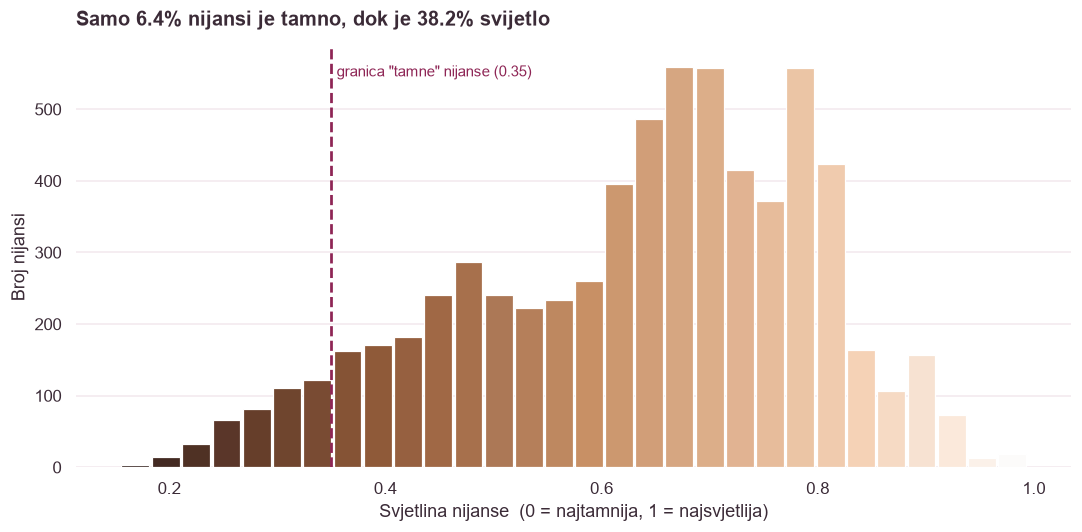

In [170]:
fig, ax = plt.subplots(figsize=(10, 5))

sirina = (granice[1] - granice[0]) * 0.92
ax.bar(sredine, po_binu['broj'], width=sirina, color=boje, edgecolor='white', linewidth=0.8)

ax.axvline(0.35, color=ROZA_TAMNA, linestyle='--', linewidth=1.8)
ax.text(0.355, ax.get_ylim()[1] * 0.93, 'granica "tamne" nijanse (0.35)',
        fontsize=10, color=ROZA_TAMNA)

ax.set_title("Samo 6.4% nijansi je tamno, dok je 38.2% svijetlo", loc='left', pad=14)
ax.set_xlabel("Svjetlina nijanse  (0 = najtamnija, 1 = najsvjetlija)")
ax.set_ylabel("Broj nijansi")
ax.grid(axis='x', visible=False)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

Vrh je između 0.65 i 0.80, a lijevi rep je tanak. Lijevo od isprekidane linije,
dakle u cijeloj tamnoj zoni, stoji 430 od 6.730 nijansi.

Boje stupaca pokazuju da ovo nije apstraktna skala nego stvarni puderi.

### Graf 2: ko pokriva tamnije tonove

Stavljam 12 brendova sa najvećim udjelom tamnih i 8 onih koji nemaju nijednu, da
se razlika vidi u istom kadru.

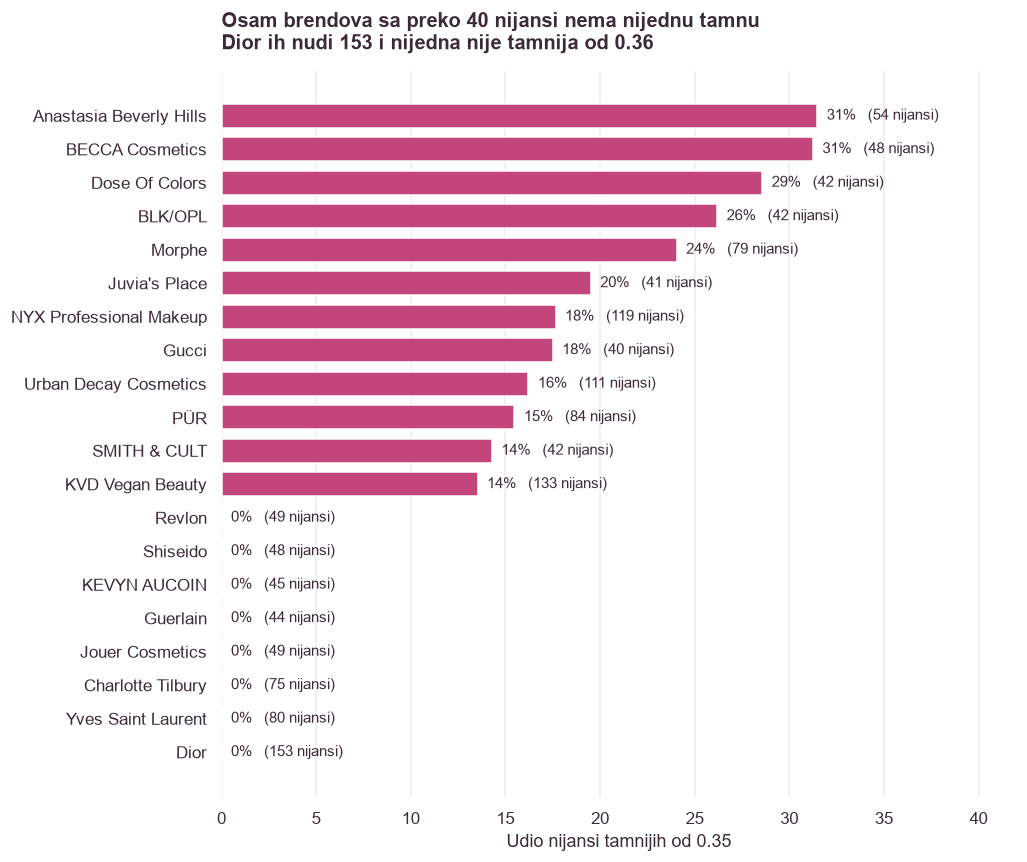

In [171]:
gore  = pregled.sort_values('udio_tamnih', ascending=False).head(12)
dolje = pregled[pregled['udio_tamnih'] == 0].sort_values('broj_nijansi', ascending=False)

prikaz = pd.concat([gore, dolje]).sort_values('udio_tamnih')

fig, ax = plt.subplots(figsize=(9.5, 8))

boje_traka = [ROZA_SVIJ if v == 0 else ROZA for v in prikaz['udio_tamnih']]
ax.barh(prikaz.index, prikaz['udio_tamnih'], color=boje_traka, height=0.72)

for y, (udio, n) in enumerate(zip(prikaz['udio_tamnih'], prikaz['broj_nijansi'])):
    ax.text(udio + 0.5, y, f"{udio:.0f}%   ({n} nijansi)",
            va='center', fontsize=9.5, color=TEKST)

ax.set_title("Osam brendova sa preko 40 nijansi nema nijednu tamnu\nDior ih nudi 153 i nijedna nije tamnija od 0.36",
             loc='left', pad=14)
ax.set_xlabel("Udio nijansi tamnijih od 0.35")
ax.set_xlim(0, 42)
ax.grid(axis='y', visible=False)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

Na vrhu su Anastasia Beverly Hills i BECCA sa oko 31%. Na dnu osam brendova sa
nula posto, među njima i Dior sa 153 nijanse, skoro tri puta više nego što ih ima
Anastasia.

Broj u zagradi je namjerno uz svaku traku, jer bez njega se ta razlika uopšte ne
bi vidjela.

### Graf 3: znači li više nijansi i više tamnih

Odnos dvije brojevne varijable, pa scatter. Liniju trenda računam sa `np.polyfit`,
to je povlačenje najbolje prave kroz tačke.

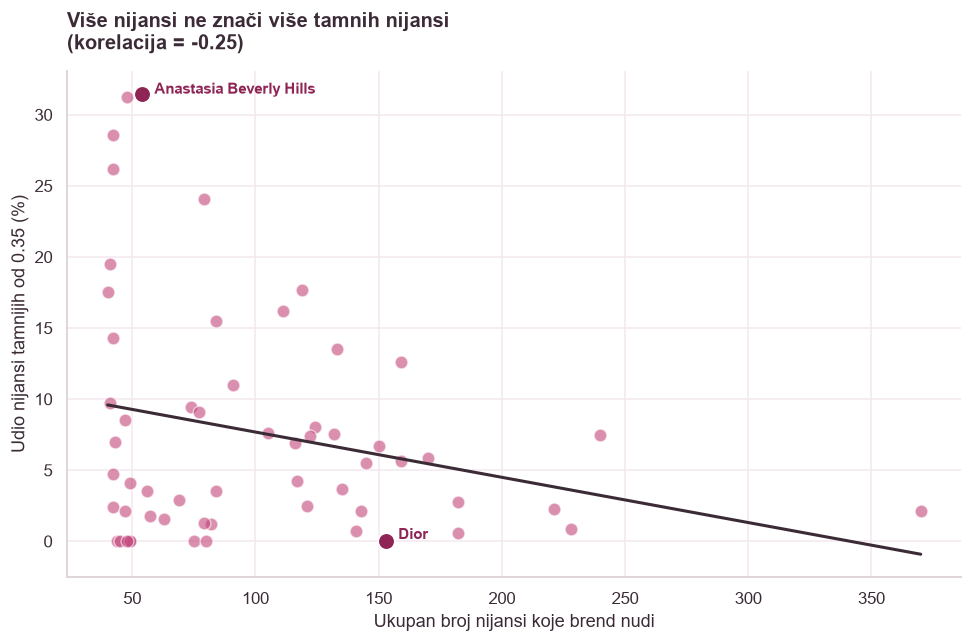

In [172]:
korelacija = pregled['broj_nijansi'].corr(pregled['udio_tamnih'])

x = pregled['broj_nijansi']
y = pregled['udio_tamnih']

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(x, y, color=ROZA, alpha=0.6, s=70, edgecolors='white', linewidths=0.9)

a, b = np.polyfit(x, y, 1)
x_lin = np.linspace(x.min(), x.max(), 100)
ax.plot(x_lin, a * x_lin + b, color=TEKST, linewidth=2)

# Istiem dva brenda koja najbolje pokazuju poentu
for ime, pomak in [('Dior', (8, 1.5)), ('Anastasia Beverly Hills', (8, 0))]:
    if ime in pregled.index:
        red = pregled.loc[ime]
        ax.scatter([red['broj_nijansi']], [red['udio_tamnih']],
                   color=ROZA_TAMNA, s=120, zorder=5, edgecolors='white', linewidths=1.2)
        ax.annotate(ime,
                    (red['broj_nijansi'], red['udio_tamnih']),
                    textcoords="offset points", xytext=pomak,
                    fontsize=10, fontweight='bold', color=ROZA_TAMNA)

ax.set_title(f"Više nijansi ne znači više tamnih nijansi\n(korelacija = {korelacija:.2f})",
             loc='left', pad=14)
ax.set_xlabel("Ukupan broj nijansi koje brend nudi")
ax.set_ylabel("Udio nijansi tamnijih od 0.35 (%)")
sns.despine()
plt.tight_layout()
plt.show()

Korelacija je -0.25, dakle blago negativna. Linija trenda pada umjesto da raste.

Brendovi koji su proširili ponudu nisu to proširenje usmjerili ka tamnijim
tonovima, nego su dodavali još varijacija tamo gdje su već bili.

> Korelacija nije uzročnost, a ova je i slaba. Ne tvrdim da veći broj nijansi
> uzrokuje manje tamnih. Tvrdim samo da veliki broj nijansi nije dokaz
> inkluzivnosti, a u marketingu se obično tako predstavlja.

## Korak 8: zaključci

---

### 1. Tržište je jako nagnuto ka svijetlim tonovima

Od 6.730 nijansi koliko ostaje nakon čišćenja, samo 6.4% je tamnije od 0.35, a
38.2% je svjetlije od 0.70. Medijan je 0.66.

Dakle polovina svih nijansi na tržištu je svjetlija od 0.66, a cijela tamna zona
stane u jedan tanak rep.

### 2. Veći broj nijansi nije dokaz inkluzivnosti

Ovo me najviše iznenadilo. Korelacija između ukupnog broja nijansi i udjela
tamnih je -0.25, dakle blago negativna.

Najjasniji primjer: Dior nudi 153 nijanse i nijedna nije tamnija od 0.36.
Anastasia Beverly Hills ima tri puta manje nijansi, svega 54, ali je 31% njih
tamno. Veličina palete i njen domet su dvije različite stvari.

### 3. Osam velikih brendova nema nijednu tamnu nijansu

Od 58 brendova koji nude 40 ili više nijansi, njih osam nema nijednu ispod 0.35:
Dior, Yves Saint Laurent, Charlotte Tilbury, Jouer, Revlon, Shiseido, Kevyn
Aucoin i Guerlain.

Kod Guerlaina je najtamnija nijansa na 0.49, što je svjetlije od medijana cijelog
tržišta. Njihova najtamnija opcija je svjetlija od prosječne nijanse u ponudi
svih brendova zajedno.

---

### Šta bih dalje istražila

- Je li se stanje popravilo kroz vrijeme, imaju li noviji proizvodi širi raspon
- Razlikuju li se drogerijski brendovi od luksuznih
- Koriste li nazivi tamnijih nijansi drugačiji rječnik od svijetlih, što je bila
  originalna tema projekta The Pudding iz kojeg dataset dolazi

### Šta sam naučila

- Prazna vrijednost nije automatski greška. `name` i `specific` su prazni kod oko
  četvrtine nijansi, ali nijedna nije bez oba naziva. Mehaničko brisanje odnijelo
  bi četvrtinu podataka.
- Nemoguća vrijednost zna odvesti do stvarnog otkrića. `hue` od 230 nije bila
  greška u mjerenju nego trag do 17 praznih bijelih slika koje su se vodile kao
  nijanse.
- Kolona sa jednom jedinom vrijednošću je beskorisna. `colorspace` ima "RGB" u
  svih 6.816 redova.
- Naslov grafa treba biti zaključak a ne opis osa. Čim sam promijenila "Broj
  nijansi po svjetlini" u "Samo 6.4% nijansi je tamno", graf je počeo nešto
  govoriti.

---

## Napomena o korištenju AI alata

Profesorica je u zadaći tražila da zapišemo gdje nam je AI pomogao, a gdje je
predložio nešto pogrešno. Koristila sam AI pri izradi ove analize i evo iskreno
kako je to izgledalo.

Bitno mi je naglasiti **kako** smo radili. AI nije dobio nikakve gotove
materijale ni gotovu analizu da je samo prepiše. Notebook smo gradili funkciju po
funkciju, gdje sam ja govorila koje formule i operacije želim koristiti i kakvu
analizu hoću da napravim, a on je pisao sintaksu i objašnjavao šta koja operacija
radi. Iskreno, složenije funkcije sama ne bih znala napisati u datom trenutku, a ni sam notebook ne bih znala kreirati jer se s tim do sada nisam susretala.

**Gdje je pomogao:**

- Provjera dataseta, je li pogodan za korištenje i učitava li se URL stvarno
- Kreiranje samog notebooka i uređivanje teksta
- Funkcija koja hex zapis pretvara u RGB vrijednosti, i petlja koja zatim boji
  stupce histograma prosječnom bojom nijansi iz tog opsega. To sama ne bih znala
  napisati iz prve.
- Struktura `groupby` sa `agg` za više mjera odjednom
- Objašnjenja šta pojedina pandas operacija radi, što mi je bilo korisnije od
  samog koda

**Gdje je trebalo provjeriti:**

- Prvi prijedlog za nedostajuće vrijednosti bio je obrisati redove sa `NaN`. Da
  sam to uradila, izgubila bih oko četvrtine dataseta. Tek kad sam provjerila da
  li su `name` i `specific` ikad **oba** prazna (nisu), bilo je jasno da brisanje
  nema smisla.
- Neobične vrijednosti u koloni `hue` prvo su objašnjene kao greška u podacima.
  Tek pogled u `hex` i `sat` pokazao je da se radi o praznim bijelim slikama.
  Objašnjenje koje zvuči uvjerljivo nije isto što i provjereno objašnjenje.
- Granice za kategorije svjetline (0.35 i 0.70) su moja odluka, ne nešto što
  postoji u podacima. Drugačije granice dale bi drugačije procente, pa ih navodim
  otvoreno umjesto da ih predstavljam kao objektivne.

**Zaključak:** AI je bio koristan za pisanje koda i za objašnjavanje operacija
koje još ne znam napamet, ili kad imam ideju za implementaciju a ne znam samu
sintaksu i kako to sve spojiti. Nije bio pouzdan kod odluka o tome **šta podaci
znače**, gdje je iz svake jednostavne analize izvlačio kompleksnije zaključke
nego što je bila sama poenta analize. Svaki put kad sam provjerila tvrdnju
umjesto da je prihvatim, nešto se promijenilo u analizi.